## PyLops integration in DeepInv - PostStack example

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import deepinv as dinv

from functools import partial
from scipy.signal import filtfilt
from pylops.utils.wavelets import *
from pylops.avo.poststack import *

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
device

'cpu'

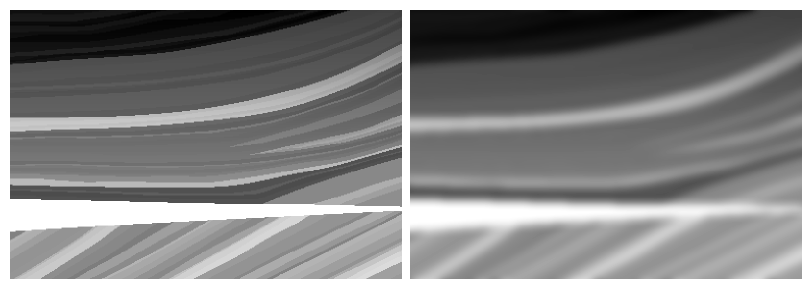

In [ ]:
inputfile = '../data/avo/poststack_model.npz'

model = np.load(inputfile)
x, z, m = model['x'], model['z'], np.log(model['model'])
m = m / m.max()
nx, nz = len(x), len(z)

nsmooth = 40
mback = filtfilt(np.ones(nsmooth)/float(nsmooth), 1, m, axis=0)
mback = filtfilt(np.ones(nsmooth)/float(nsmooth), 1, mback, axis=1)

m_t = torch.from_numpy(m.astype(np.float32)).unsqueeze(0).unsqueeze(0)
mback_t = torch.from_numpy(mback.astype(np.float32).copy()).unsqueeze(0).unsqueeze(0)

dinv.utils.plot([m_t, mback_t], figsize=(8,5))

In [3]:
from pylops import TorchOperator

# class DeepInvOperator(dinv.physics.LinearPhysics):
#     def __init__(self, Op, **kwargs):
#         super().__init__(**kwargs)
#         self.Op = TorchOperator(Op, batch=True)
        
#     def A(
#         self, x: torch.Tensor, **kwargs
#     ) -> torch.Tensor:
#         """Forward operator.

#         :param torch.Tensor x: input image with 3 color (RGB) channels, i.e. [*,3,*,*]
#         :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
#         :return: torch.Tensor grayscale measurements
#         """
#         super().update_parameters(**kwargs)
        
#         y = self.Op(x.reshape(x.shape[0], -1)).reshape(x.shape)
#         return y
    

class DeepInvOperator(dinv.physics.LinearPhysics):
    def __init__(self, Op, **kwargs):
        super().__init__(**kwargs)
        self.Op = TorchOperator(Op, batch=True, )

    def A(
        self, x: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Forward operator.

        :param torch.Tensor x: input image with 3 color (RGB) channels, i.e. [*,3,*,*]
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor grayscale measurements
        """
        super().update_parameters(**kwargs)
        
        x = x.detach().numpy()
        y = torch.from_numpy(self.Op.matvec(x.reshape(x.shape[0], -1)).reshape(x.shape))
        return y
    
    def A_adjoint(
        self, y: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Closed-form adjoint operator.

        :param torch.Tensor y: input grayscale measurements
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor adjoint reconstruction
        """
        super().update_parameters(**kwargs)

        y = y.detach().numpy()
        x = torch.from_numpy(self.Op.rmatvec(y.reshape(y.shape[0], -1)).reshape(y.shape))
        return x


In [4]:
nt0 = nz
dt0 = 0.004
t0  = np.arange(nt0)*dt0

ntwav = 41
wav = ricker(t0[:ntwav//2+1], 15)[0]

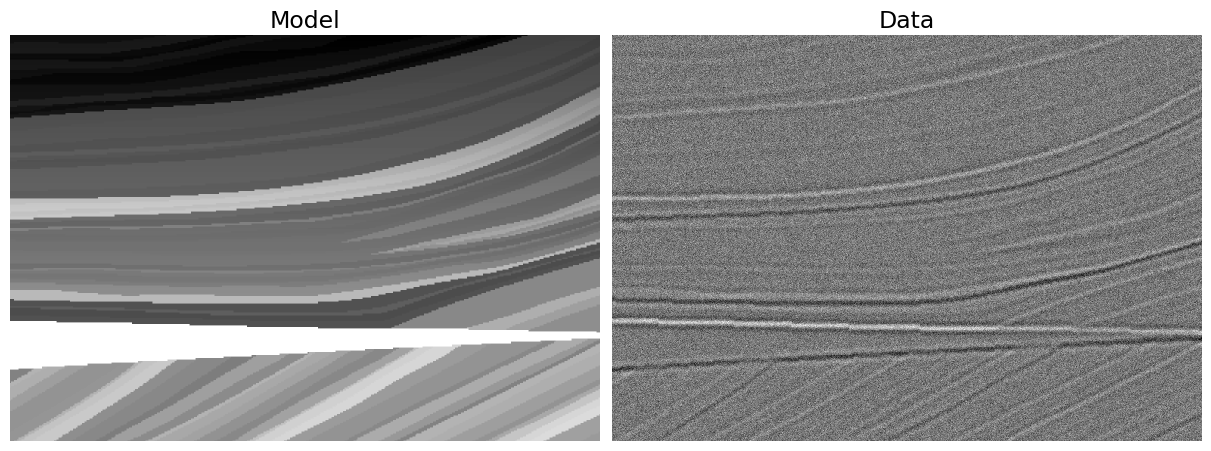

In [5]:
POp = PoststackLinearModelling(wav.astype(np.float32), nt0=nz,
                               spatdims=nx,
                               explicit=False)
# TOp = TorchOperator(POp, batch=False, )
# TOp(m_t[0, 0])

physics = DeepInvOperator(POp, img_size=m_t.shape[2:])

# Simulate measurements
d_t = physics(m_t)

# Add noise
sigma_n = 0.1
d_t = d_t + sigma_n * torch.randn(d_t.shape)

# Display
dinv.utils.plot(
    {
        "Model": m_t,
        "Data": d_t,
    },
    figsize=(12, 8)
)

LSQR did not converge


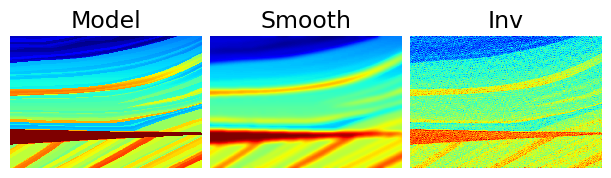

In [6]:
# Inverse
from deepinv.optim.utils import least_squares

A  = physics.A
AT = physics.A_adjoint

minv_t = least_squares(
    A=A,
    AT=AT,
    y=d_t,
    z=mback_t,
    gamma=1e10 if sigma_n == 0 else 1e1,
    solver= "lsqr",
    max_iter=100,
    tol=0,
    verbose=True,
)

dinv.utils.plot(
    {
        "Model": m_t,
        "Smooth": mback_t,
        "Inv": minv_t,
    },
    cmap="jet",
)

In [7]:
from __future__ import annotations
from torch import Tensor
from deepinv.models import DRUNet
from deepinv.models.base import Denoiser
from deepinv.optim.data_fidelity import L2
from deepinv.optim.prior import PnP
from deepinv.optim.optimizers import create_iterator
from deepinv.optim import BaseOptim
import torch


def get_DPIR_params(noise_level_img: float, device: str | torch.device = "cpu"):
    r"""
    Default parameters for the DPIR Plug-and-Play algorithm.

    :param float noise_level_img: Noise level of the input image.
    :param str, torch.device device: Device to run the algorithm, either "cpu" or "cuda". Default is "cpu".
    :return: tuple(list with denoiser noise level per iteration, list with stepsize per iteration, iterations).
    """
    max_iter = 8
    s1 = 49.0 / 255.0
    s2 = noise_level_img
    sigma_denoiser = torch.logspace(
        torch.log10(torch.tensor(s1, dtype=torch.float32)),
        torch.log10(torch.tensor(s2, dtype=torch.float32)),
        steps=max_iter,
        dtype=torch.float32,
        device=device,
    )

    stepsize = (sigma_denoiser / max(0.01, noise_level_img)) ** 2
    lamb = 1 / 0.23

    return sigma_denoiser, lamb * stepsize, max_iter


class DPIR(BaseOptim):
    r"""
    Deep Plug-and-Play (DPIR) algorithm for image restoration.

    The method is based on half-quadratic splitting (HQS) and a PnP prior with a pretrained denoiser :class:`deepinv.models.DRUNet`.
    The optimization is stopped early and the noise level for the denoiser is adapted at each iteration.
    See :ref:`sphx_glr_auto_examples_plug-and-play_demo_PnP_DPIR_deblur.py` for more details on the implementation,
    and how to adapt it to your specific problem.

    This method uses a standard :math:`\ell_2` data fidelity term.

    The DPIR method is described in :footcite:t:`zhang2021plug`.

    :param float, torch.Tensor sigma: Standard deviation of the measurement noise, which controls the choice of the
        rest of the hyperparameters of the algorithm. Default is ``0.1``.
    :param deepinv.models.Denoiser denoiser: optional denoiser. If `None`, use a pretrained denoiser :class:`deepinv.models.DRUNet`.
    :param str, torch.device device: Device to run the algorithm, either "cpu" or "cuda". Default is "cpu".


    """

    def __init__(
        self,
        x0,
        sigma: float | Tensor = 0.1,
        denoiser: Denoiser = None,
        device: str | torch.device = "cpu",
    ):  
        def init(y, physics, x0):
            return {"est": (x0, x0)}
        
        prior = PnP(
            denoiser=(
                DRUNet(pretrained="download", device=device)
                if denoiser is None
                else denoiser
            )
        )
        sigma_denoiser, stepsize, max_iter = get_DPIR_params(sigma, device=device)
        params_algo = {"stepsize": stepsize, "g_param": sigma_denoiser}
        super(DPIR, self).__init__(
            create_iterator("HQS", prior=prior, F_fn=None, g_first=False),
            custom_init=partial(init, x0=x0),
            max_iter=max_iter,
            data_fidelity=L2(),
            prior=prior,
            early_stop=False,
            params_algo=params_algo,
        )


In [8]:
model = DPIR(x0=mback_t, 
             denoiser=dinv.models.DRUNet(1, 1), 
             sigma=sigma_n,
             device=device)

mdipr_t = model.forward(d_t, physics)

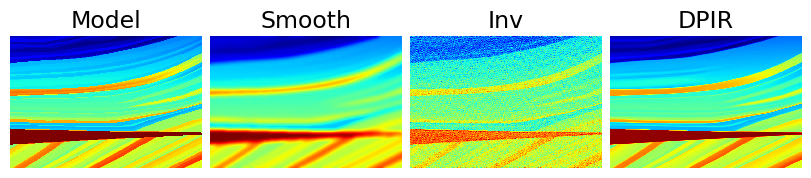

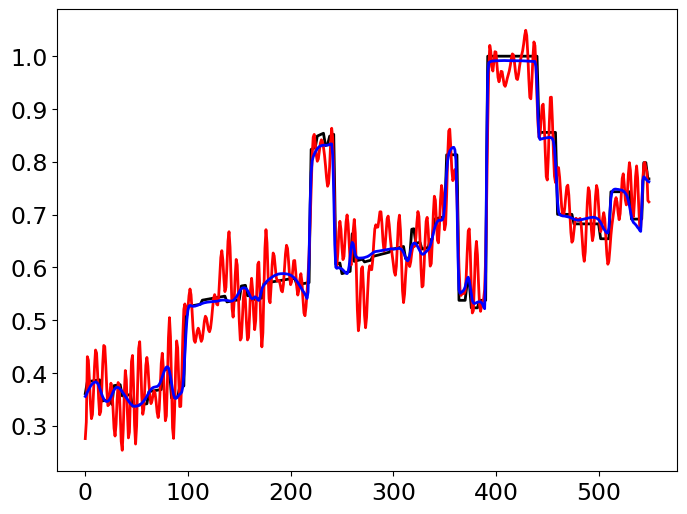

In [9]:
dinv.utils.plot(
    {
        "Model": m_t,
        "Smooth": mback_t,
        "Inv": minv_t,
        "DPIR": mdipr_t,
    },
    cmap="jet",
)

plt.figure()
plt.plot(m_t[0,0,:, 200], 'k')
plt.plot(minv_t[0,0,:, 200], 'r')
plt.plot(mdipr_t[0,0,:, 200], 'b');

In [11]:
class DeepInvOperator(dinv.physics.LinearPhysics):
    def __init__(self, Op, **kwargs):
        super().__init__(**kwargs)
        self.Op = TorchOperator(Op, batch=True)
        
    def A(
        self, x: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Forward operator.

        :param torch.Tensor x: input image with 3 color (RGB) channels, i.e. [*,3,*,*]
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor grayscale measurements
        """
        super().update_parameters(**kwargs)
        
        y = self.Op(x.reshape(x.shape[0], -1)).reshape(x.shape)
        return y

In [16]:
physics = DeepInvOperator(POp, img_size=m_t.shape[2:])
d_t = physics(m_t)

model = dinv.sampling.DPS(dinv.models.DRUNet(1, 1), 
                          data_fidelity=dinv.optim.data_fidelity.L2(),
                          max_iter=100, verbose=True)
mdps_t = model(d_t, physics)

100%|██████████| 100/100 [34:31<00:00, 20.72s/it]


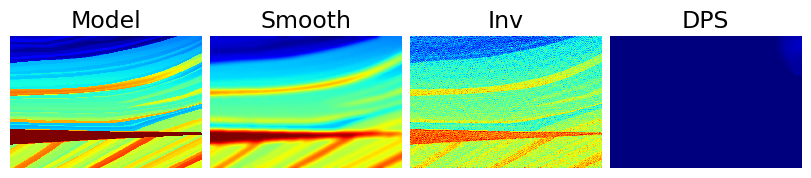

In [17]:
dinv.utils.plot(
    {
        "Model": m_t,
        "Smooth": mback_t,
        "Inv": minv_t,
        "DPS": mdps_t,
    },
    cmap="jet",
)

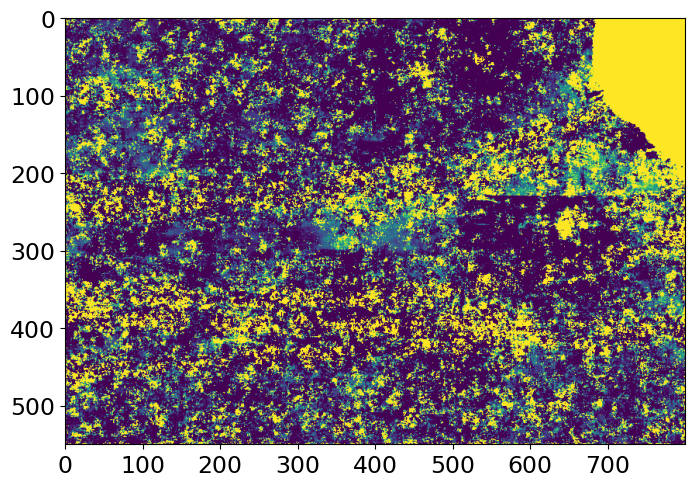

In [26]:
plt.imshow(mdps_t.detach()[0, 0] + 1, vmin=0, vmax=1e-5)

In [ ]:
# Norm
phy_norm = physics.compute_norm(torch.randn(mback_t.shape))
phy_norm1 = (POp.H @ POp).eigs(1, niter=10, tol=1e-2)
phy_norm, phy_norm1

Power iteration converged at iteration 47, ||A^T A||_2=7.82


(tensor(7.8191), array([7.8529234+0.j], dtype=complex64))

In [ ]:
# Pseudo-inv
physics.A_dagger(d_t)

tensor([[[[ 0.0860, -0.4508,  0.3021,  ..., -0.3016, -0.2303,  0.0197],
          [ 0.1315, -0.5769, -0.0415,  ...,  0.4971, -0.0392,  0.0347],
          [ 0.0663, -0.2981, -0.3674,  ...,  0.8912,  0.1695, -0.0206],
          ...,
          [-0.1478,  0.4733, -0.7109,  ...,  0.1672, -0.5718, -0.5060],
          [-0.2253, -0.1155, -0.0257,  ...,  0.0461, -0.0873, -0.4546],
          [-0.0722, -0.5042,  0.5561,  ..., -0.0301,  0.3877, -0.0244]]]])